## Import Libraries

We import the necessary libraries for:
- Image processing (OpenCV)
- Feature extraction (HOG)
- Machine learning (scikit-learn)
- Data handling (NumPy)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

from skimage.feature import hog
from skimage.color import rgb2gray

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 1996
IMAGE_SIZE = (64, 64)
DATA_PATH = Path.home() / "Library" / "CloudStorage" / "GoogleDrive-jesstwentworth@gmail.com" / "My Drive" / "Machine Learning Group Project"

np.random.seed(RANDOM_STATE)

def summarize_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

def load_dataset(aug_version):
    X_train = np.load(DATA_PATH / f"X_train_{aug_version}.npy")
    X_val   = np.load(DATA_PATH / f"X_val_{aug_version}.npy")
    X_test  = np.load(DATA_PATH / f"X_test_{aug_version}.npy")

    y_train = np.load(DATA_PATH / f"y_train_{aug_version}.npy")
    y_val   = np.load(DATA_PATH / f"y_val_{aug_version}.npy")
    y_test  = np.load(DATA_PATH / f"y_test_{aug_version}.npy")

    return X_train, X_val, X_test, y_train, y_val, y_test

def extract_hog_features(image_flat):
    image = image_flat.reshape(64, 64, 3)
    image_gray = rgb2gray(image)
    return hog(
        image_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False
    )

def transform_split_with_hog(X_train, X_val, X_test):
    X_train_hog = np.array([extract_hog_features(img) for img in X_train])
    X_val_hog   = np.array([extract_hog_features(img) for img in X_val])
    X_test_hog  = np.array([extract_hog_features(img) for img in X_test])
    return X_train_hog, X_val_hog, X_test_hog

def run_random_forest_experiment(aug_version):
    X_train, X_val, X_test, y_train, y_val, y_test = load_dataset(aug_version)

    print(f"\nDataset Loaded: {aug_version}")
    print("-" * 50)
    print("Train shape:", X_train.shape, "|", y_train.shape)
    print("Val shape:  ", X_val.shape,   "|", y_val.shape)
    print("Test shape: ", X_test.shape,  "|", y_test.shape)
    print("Data type:", X_train.dtype)
    print("Pixel range:", X_train.min(), "to", X_train.max())
    print("Number of classes:", len(np.unique(y_train)))

    X_train_hog, X_val_hog, X_test_hog = transform_split_with_hog(X_train, X_val, X_test)

    print("\nHOG feature shapes")
    print("Train:", X_train_hog.shape)
    print("Val:  ", X_val_hog.shape)
    print("Test: ", X_test_hog.shape)

    rf_classifier = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf_classifier.fit(X_train_hog, y_train)

    y_val_pred = rf_classifier.predict(X_val_hog)
    y_test_pred = rf_classifier.predict(X_test_hog)

    val_accuracy = accuracy_score(y_val, y_val_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"\nValidation Accuracy ({aug_version}): {val_accuracy:.2%}")
    print(f"Test Accuracy ({aug_version}): {test_accuracy:.2%}")

    results = summarize_model(f"Random Forest ({aug_version})", y_test, y_test_pred)
    results["Validation Accuracy"] = val_accuracy

    return {
        "aug_version": aug_version,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "X_train_hog": X_train_hog,
        "X_val_hog": X_val_hog,
        "X_test_hog": X_test_hog,
        "model": rf_classifier,
        "y_val_pred": y_val_pred,
        "y_test_pred": y_test_pred,
        "results": results
    }

def plot_rf_accuracy_curve(experiment, tree_grid=[10, 25, 50, 100, 200]):
    X_train_hog = experiment["X_train_hog"]
    X_val_hog   = experiment["X_val_hog"]
    X_test_hog  = experiment["X_test_hog"]
    y_train     = experiment["y_train"]
    y_val       = experiment["y_val"]
    y_test      = experiment["y_test"]
    aug_version = experiment["aug_version"]

    curve_results = []

    for n_trees in tree_grid:
        rf = RandomForestClassifier(
            n_estimators=n_trees,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        rf.fit(X_train_hog, y_train)

        train_pred = rf.predict(X_train_hog)
        val_pred   = rf.predict(X_val_hog)
        test_pred  = rf.predict(X_test_hog)

        curve_results.append({
            "n_estimators": n_trees,
            "Train Accuracy": accuracy_score(y_train, train_pred),
            "Validation Accuracy": accuracy_score(y_val, val_pred),
            "Test Accuracy": accuracy_score(y_test, test_pred)
        })

    curve_df = pd.DataFrame(curve_results)

    plt.figure(figsize=(8, 5))
    plt.plot(curve_df["n_estimators"], curve_df["Validation Accuracy"], marker="o", label="Validation Accuracy")
    plt.plot(curve_df["n_estimators"], curve_df["Test Accuracy"], marker="o", label="Test Accuracy")
    plt.xlabel("Number of Trees")
    plt.ylabel("Accuracy")
    plt.title(f"Random Forest Accuracy Curve - {aug_version}")
    plt.ylim(0, max(curve_df["Validation Accuracy"].max(), curve_df["Test Accuracy"].max()) + 0.05)
    plt.legend()
    plt.grid(True)
    plt.show()

    return curve_df

## Dataset Overview: Aug5

This section loads the **aug5** dataset, checks shape and class balance, and previews example images.

In [2]:
aug5_data = load_dataset("5aug")
X_train_5, X_val_5, X_test_5, y_train_5, y_val_5, y_test_5 = aug5_data

print("Dataset Loaded: 5aug")
print("-" * 40)
print("Train shape:", X_train_5.shape, "|", y_train_5.shape)
print("Val shape:  ", X_val_5.shape,   "|", y_val_5.shape)
print("Test shape: ", X_test_5.shape,  "|", y_test_5.shape)
print("Data type:", X_train_5.dtype)
print("Pixel range:", X_train_5.min(), "to", X_train_5.max())
print("Number of classes:", len(np.unique(y_train_5)))

class_counts_5 = __import__('pandas').Series(y_train_5).value_counts().sort_index()
print("\nFirst 10 class counts (aug5):")
print(class_counts_5.head(10))
print("\nTotal training images (aug5):", len(y_train_5))

# RUNTIME: .5sec

Dataset Loaded: 5aug
----------------------------------------
Train shape: (21744, 12288) | (21744,)
Val shape:   (1208, 12288) | (1208,)
Test shape:  (1208, 12288) | (1208,)
Data type: float32
Pixel range: 0.0 to 1.0
Number of classes: 151

First 10 class counts (aug5):
abra          144
aerodactyl    144
alakazam      144
arbok         144
arcanine      144
articuno      144
beedrill      144
bellsprout    144
blastoise     144
bulbasaur     144
Name: count, dtype: int64

Total training images (aug5): 21744


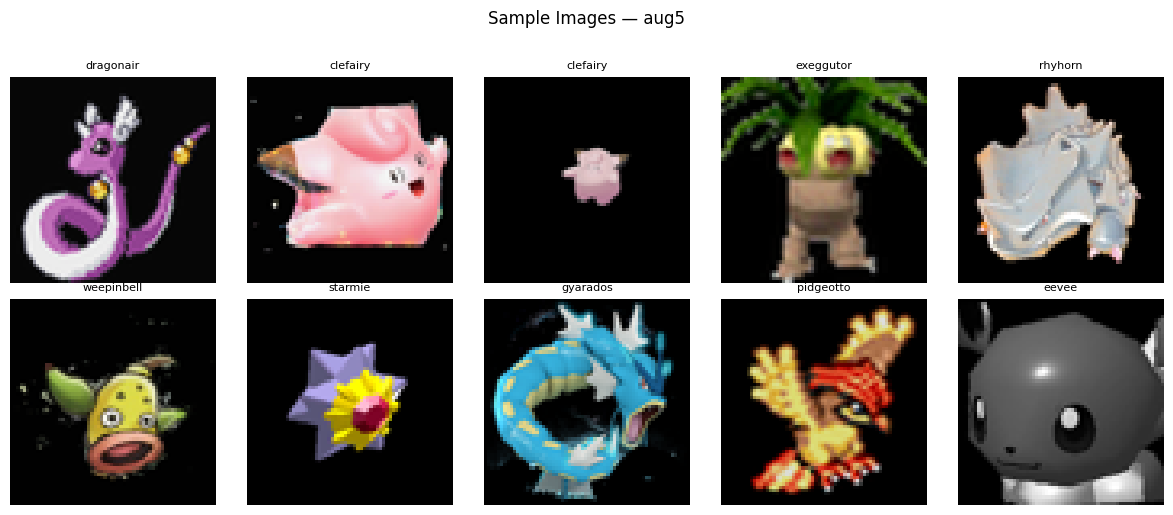

In [3]:
rng = np.random.default_rng(RANDOM_STATE)
indices = rng.choice(len(X_train_5), 10, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    img = X_train_5[idx].reshape(64, 64, 3)
    plt.imshow(img)
    plt.title(y_train_5[idx], fontsize=8)
    plt.axis("off")

plt.suptitle("Sample Images — aug5", y=1.02)
plt.tight_layout()
plt.show()

# RUNTIME: .1sec


## Dataset Overview: Aug10

This section loads the **aug10** dataset, checks shape and class balance, and previews example images.

In [4]:
aug10_data = load_dataset("10aug")
X_train_10, X_val_10, X_test_10, y_train_10, y_val_10, y_test_10 = aug10_data

print("Dataset Loaded: 10aug")
print("-" * 40)
print("Train shape:", X_train_10.shape, "|", y_train_10.shape)
print("Val shape:  ", X_val_10.shape,   "|", y_val_10.shape)
print("Test shape: ", X_test_10.shape,  "|", y_test_10.shape)
print("Data type:", X_train_10.dtype)
print("Pixel range:", X_train_10.min(), "to", X_train_10.max())
print("Number of classes:", len(np.unique(y_train_10)))

class_counts_10 = __import__('pandas').Series(y_train_10).value_counts().sort_index()
print("\nFirst 10 class counts (aug10):")
print(class_counts_10.head(10))
print("\nTotal training images (aug10):", len(y_train_10))

# RUNTIME: 2min 29sec

Dataset Loaded: 10aug
----------------------------------------
Train shape: (39864, 12288) | (39864,)
Val shape:   (1208, 12288) | (1208,)
Test shape:  (1208, 12288) | (1208,)
Data type: float32
Pixel range: 0.0 to 1.0
Number of classes: 151

First 10 class counts (aug10):
abra          264
aerodactyl    264
alakazam      264
arbok         264
arcanine      264
articuno      264
beedrill      264
bellsprout    264
blastoise     264
bulbasaur     264
Name: count, dtype: int64

Total training images (aug10): 39864


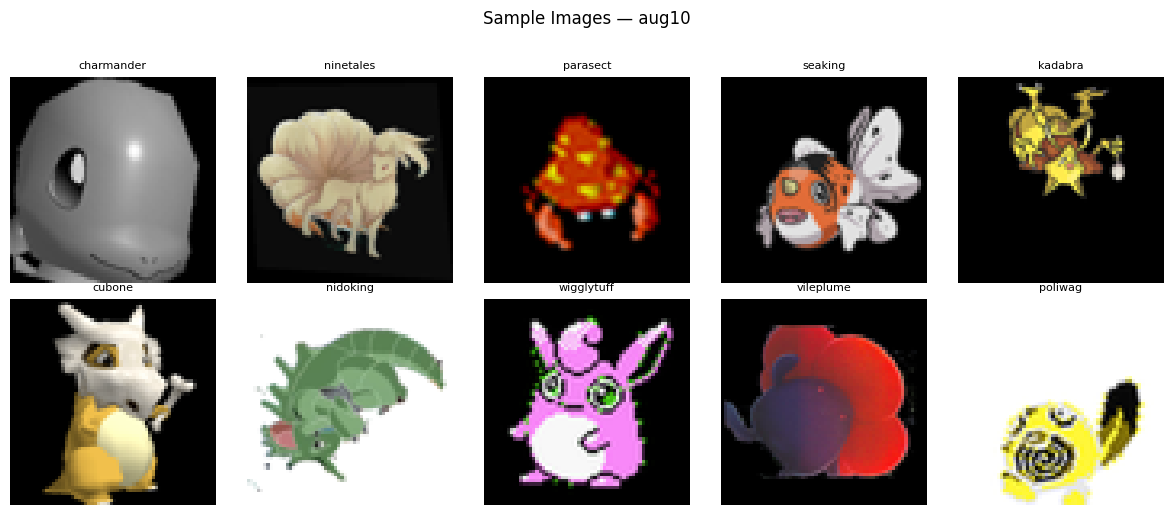

In [5]:
rng = np.random.default_rng(RANDOM_STATE + 1)
indices = rng.choice(len(X_train_10), 10, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    img = X_train_10[idx].reshape(64, 64, 3)
    plt.imshow(img)
    plt.title(y_train_10[idx], fontsize=8)
    plt.axis("off")

plt.suptitle("Sample Images — aug10", y=1.02)
plt.tight_layout()
plt.show()

# RUNTIME: .1sec

## Pixel Intensity Comparison

This compares the pixel distributions for the two dataset versions.

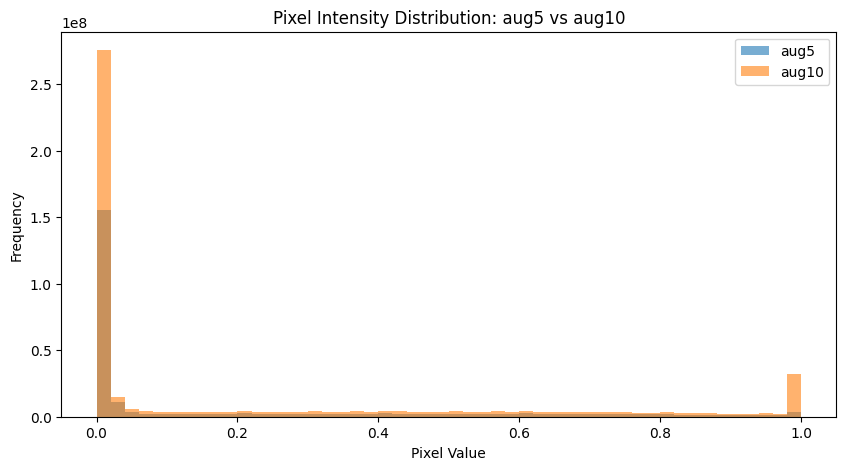

aug5 mean pixel value: 0.1862858
aug10 mean pixel value: 0.2294359


In [6]:
plt.figure(figsize=(10, 5))
plt.hist(X_train_5.flatten(), bins=50, alpha=0.6, label="aug5")
plt.hist(X_train_10.flatten(), bins=50, alpha=0.6, label="aug10")
plt.title("Pixel Intensity Distribution: aug5 vs aug10")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print("aug5 mean pixel value:", X_train_5.mean())
print("aug10 mean pixel value:", X_train_10.mean())

# RUNTIME 8secs

## Data Leakage Check

This checks overlap between training and validation splits for each dataset version.

In [7]:
def check_overlap(X_train, X_val, label):
    train_hashes = set(map(tuple, X_train.reshape(len(X_train), -1)))
    val_hashes   = set(map(tuple, X_val.reshape(len(X_val), -1)))
    overlap = train_hashes.intersection(val_hashes)
    print(f"Overlap between train and val ({label}):", len(overlap))

check_overlap(X_train_5, X_val_5, "aug5")
check_overlap(X_train_10, X_val_10, "aug10")

# RUNTIME: 27sec


Overlap between train and val (aug5): 2
Overlap between train and val (aug10): 2


## Random Forest Baseline: aug5

Train and evaluate the Random Forest model on the **aug5** dataset.



Dataset Loaded: 5aug
--------------------------------------------------
Train shape: (21744, 12288) | (21744,)
Val shape:   (1208, 12288) | (1208,)
Test shape:  (1208, 12288) | (1208,)
Data type: float32
Pixel range: 0.0 to 1.0
Number of classes: 151

HOG feature shapes
Train: (21744, 1764)
Val:   (1208, 1764)
Test:  (1208, 1764)

Validation Accuracy (5aug): 24.67%
Test Accuracy (5aug): 24.01%

Classification Report — aug5
              precision    recall  f1-score   support

        abra       0.15      0.25      0.19         8
  aerodactyl       0.27      0.50      0.35         8
    alakazam       0.23      0.62      0.33         8
       arbok       0.13      0.25      0.17         8
    arcanine       0.20      0.38      0.26         8
    articuno       0.07      0.12      0.09         8
    beedrill       0.10      0.12      0.11         8
  bellsprout       0.21      0.38      0.27         8
   blastoise       0.07      0.12      0.09         8
   bulbasaur       0.06      0.

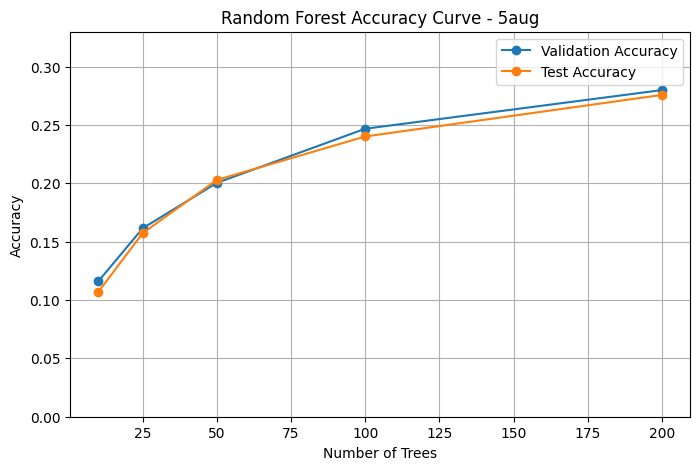

In [8]:
rf_aug5 = run_random_forest_experiment("5aug")

print("\nClassification Report — aug5")
print(classification_report(rf_aug5["y_test"], rf_aug5["y_test_pred"], zero_division=0))

aug5_curve_df = plot_rf_accuracy_curve(rf_aug5)

# RUNTIME: 43 sec

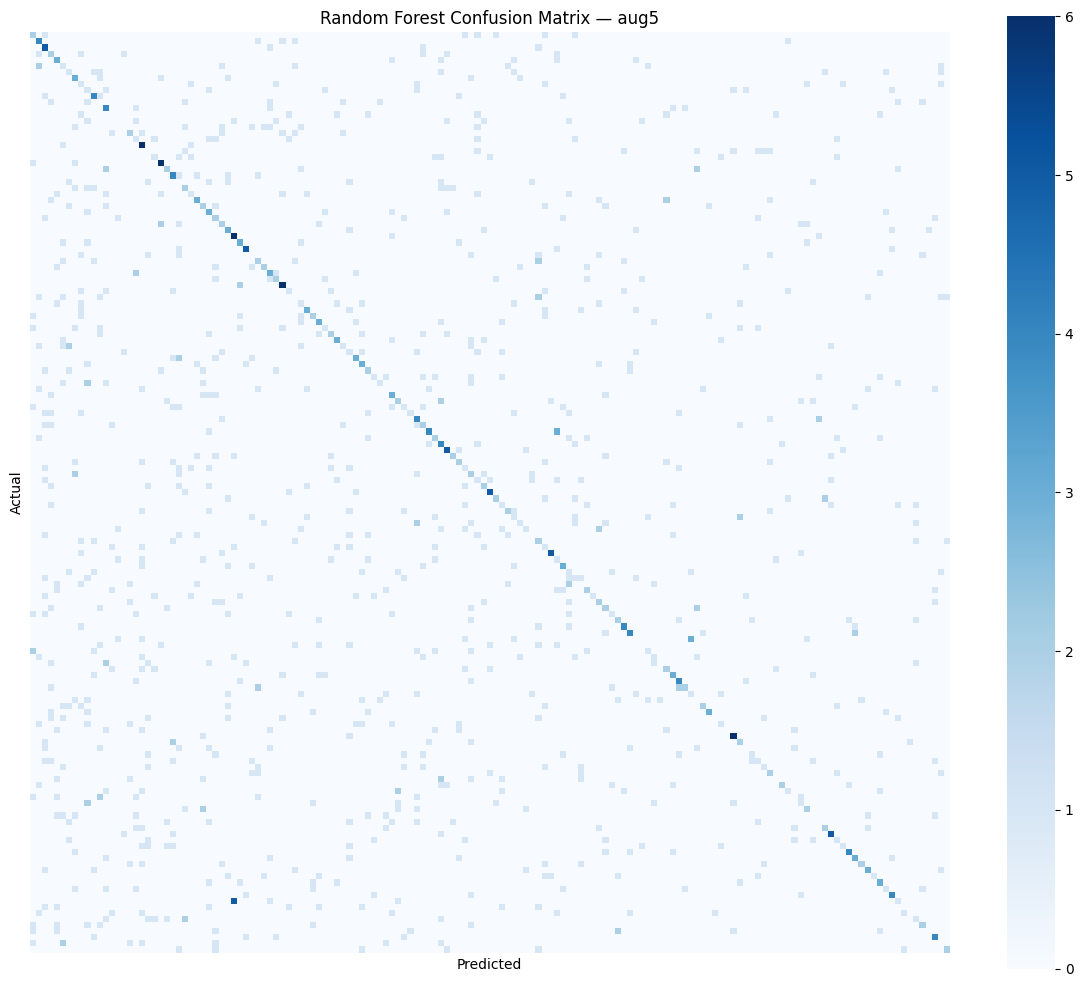

In [9]:
cm = confusion_matrix(
    rf_aug5["y_test"],
    rf_aug5["y_test_pred"]
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="Blues",
    cbar=True,
    xticklabels=False,
    yticklabels=False,
    square=True
)

plt.title("Random Forest Confusion Matrix — aug5")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Random Forest Baseline: aug10

Train and evaluate the Random Forest model on the **aug10** dataset.


Dataset Loaded: 10aug
--------------------------------------------------
Train shape: (39864, 12288) | (39864,)
Val shape:   (1208, 12288) | (1208,)
Test shape:  (1208, 12288) | (1208,)
Data type: float32
Pixel range: 0.0 to 1.0
Number of classes: 151

HOG feature shapes
Train: (39864, 1764)
Val:   (1208, 1764)
Test:  (1208, 1764)

Validation Accuracy (10aug): 23.84%
Test Accuracy (10aug): 23.84%

Classification Report — aug10
              precision    recall  f1-score   support

        abra       0.07      0.12      0.09         8
  aerodactyl       0.43      0.38      0.40         8
    alakazam       0.31      0.62      0.42         8
       arbok       0.21      0.38      0.27         8
    arcanine       0.18      0.50      0.27         8
    articuno       0.20      0.38      0.26         8
    beedrill       0.00      0.00      0.00         8
  bellsprout       0.33      0.50      0.40         8
   blastoise       0.13      0.38      0.19         8
   bulbasaur       0.00    

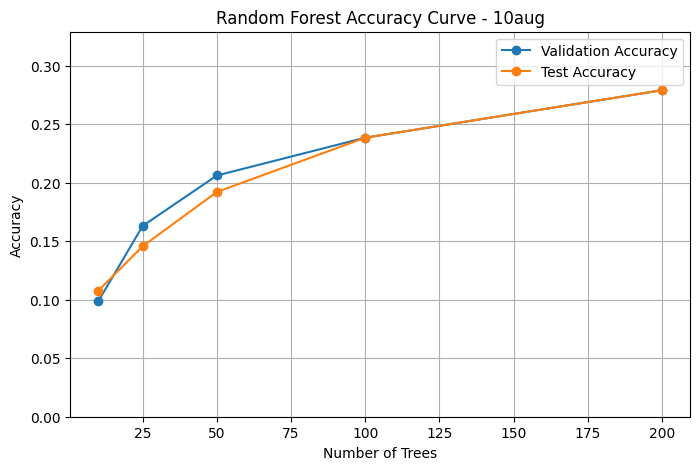

In [10]:
rf_aug10 = run_random_forest_experiment("10aug")

print("\nClassification Report — aug10")
print(classification_report(rf_aug10["y_test"], rf_aug10["y_test_pred"], zero_division=0))

aug10_curve_df = plot_rf_accuracy_curve(rf_aug10)

# RUNTIME: 6min 21sec

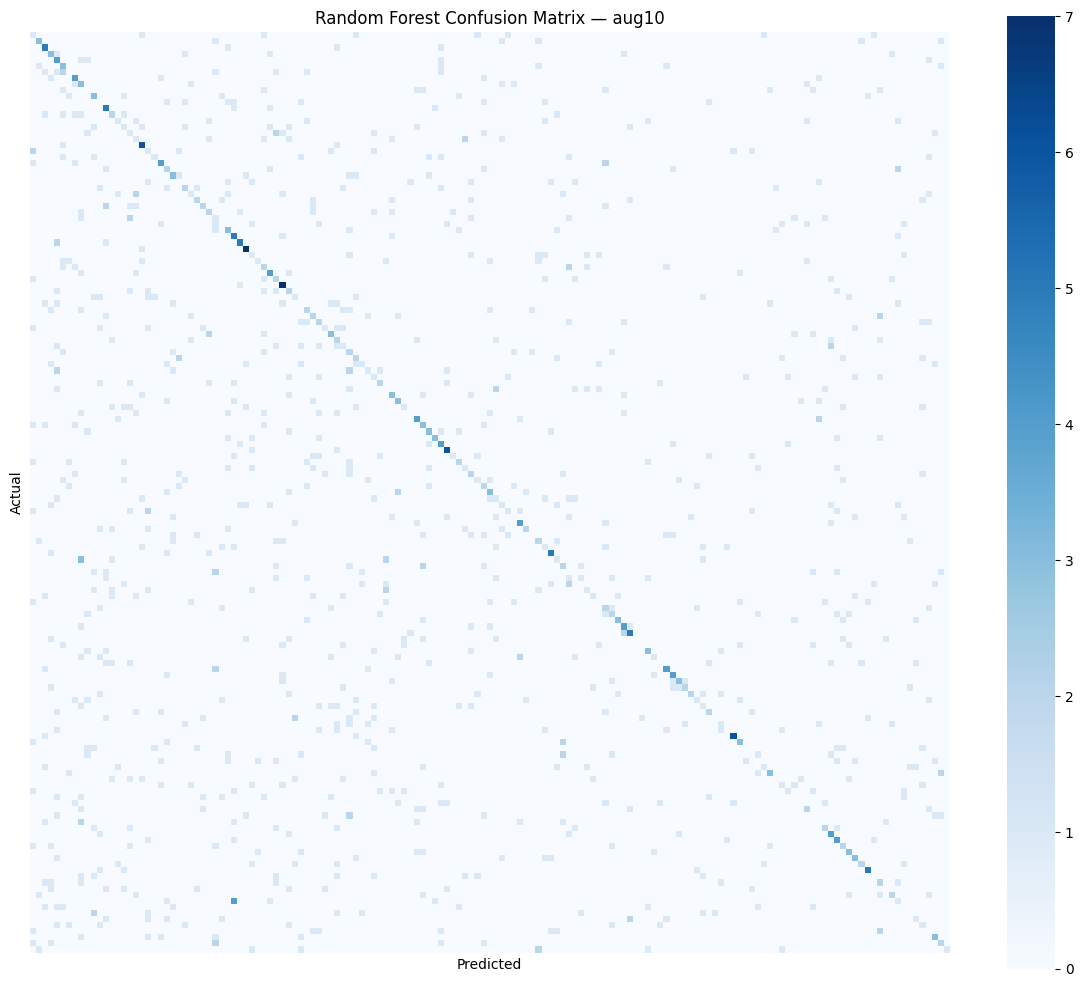

In [11]:
cm = confusion_matrix(
    rf_aug10["y_test"],
    rf_aug10["y_test_pred"]
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="Blues",
    cbar=True,
    xticklabels=False,
    yticklabels=False,
    square=True
)

plt.title("Random Forest Confusion Matrix — aug10")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Final Comparison: aug5 vs aug10

In [12]:
comparison_df = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Dataset": "5aug",
        **rf_aug5["results"]
    },
    {
        "Model": "Random Forest",
        "Dataset": "10aug",
        **rf_aug10["results"]
    }
])

comparison_df = comparison_df[
    ["Dataset", "Validation Accuracy", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]
]

print("Random Forest Comparison Table")
display(comparison_df)


Random Forest Comparison Table


,Dataset,Validation Accuracy,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,5aug,0.246689,0.240066,0.250388,0.240066,0.227950,0.227950
1,10aug,0.238411,0.238411,0.233231,0.238411,0.221229,0.221229


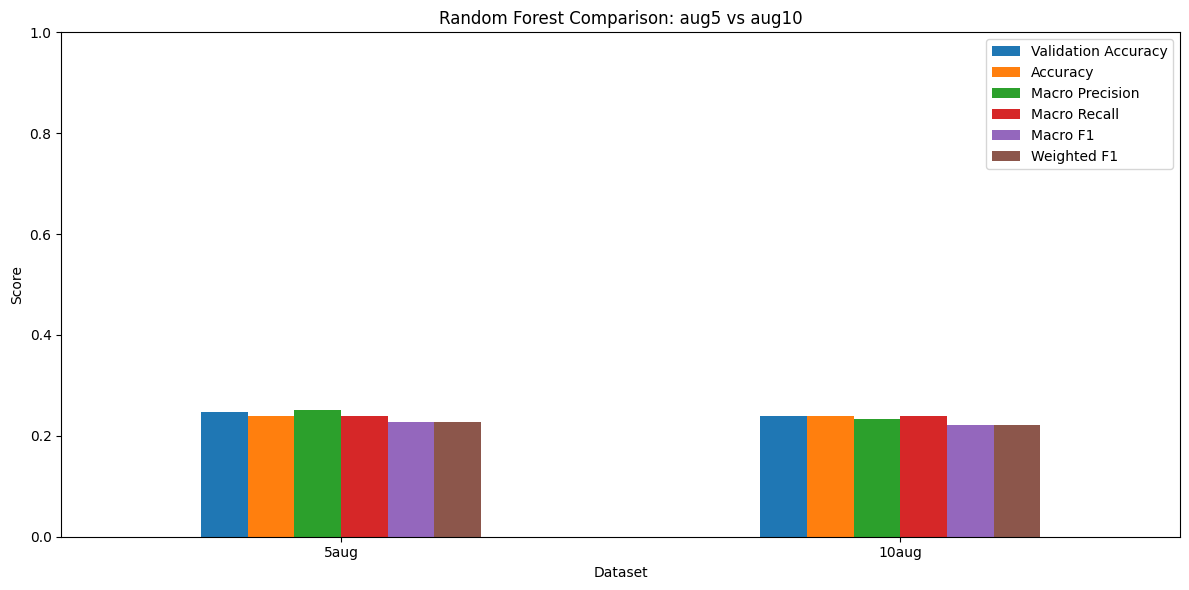

In [15]:
metrics = ["Validation Accuracy", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]

ax = comparison_df.set_index("Dataset")[metrics].plot(kind="bar", figsize=(12, 6))
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Random Forest Comparison: aug5 vs aug10")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
print(comparison_df.columns)

Index(['Dataset', 'Validation Accuracy', 'Accuracy', 'Macro Precision',
       'Macro Recall', 'Macro F1', 'Weighted F1'],
      dtype='str')
